# **Homework 1**
## ECEN 5156 - Physical Optics
### *Samuel Arnold*
### *9/8/26*
***

### 3. Plotting Exercise

#### a.) $\vec{E}$ field as a function of time and propagation distance

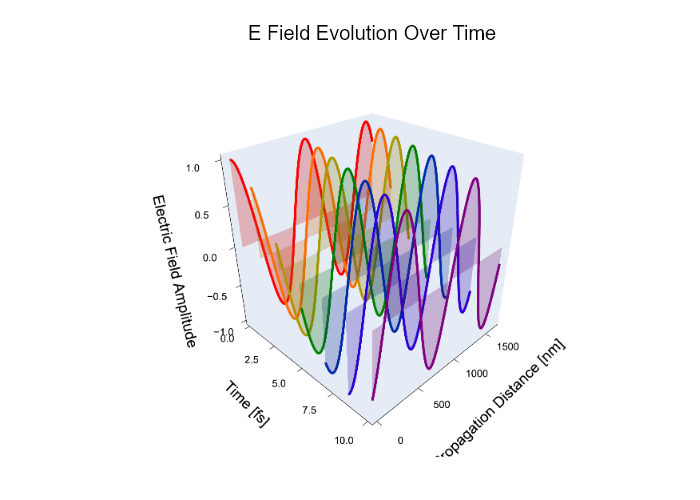

In [ ]:
using Plots
# using LaTeXStrings
# gr() 
# plotlyjs()
plotly()


# Constant Definitions
const E_0 = 1.0                         # Amplitude of E-field
const lambda_0 = 555e-9                 # Free-space wavelength (555 nm)
const k_0 = 2 * pi / lambda_0           # Wavenumber
const beta = sqrt(2) * pi / lambda_0    # Beta
const omega = 3e8 * k_0                 # Angular frequency

const y_slice = pi / (2 * beta) 

prop_distance_m = range(0, 3 * lambda_0, length=200) 
time_steps_s = range(0, 10e-15, length=7)             

colors = palette(:rainbow, length(time_steps_s))


wave_plot = plot(
    title="E Field Evolution Over Time",
    xlabel="Time [fs]",
    ylabel="Propagation Distance [nm]",
    zlabel="Electric Field Amplitude",
    camera=(45, 30),        
    legend=false,           
    size=(800, 600),
)

for (i, t) in enumerate(reverse(time_steps_s))
    E_complex = E_0 * sin(beta * y_slice) .* exp.(im .* (omega * t .- beta .* prop_distance_m))
    E = real(E_complex)
    
    plot_x_fs = fill(t * 1e15, length(prop_distance_m)) 
    plot_y_nm = prop_distance_m .* 1e9  
    
    X_ribbon = [plot_x_fs plot_x_fs]
    Y_ribbon = [plot_y_nm plot_y_nm]
    Z_ribbon = [E zeros(length(E))]
    
    surface!(
        wave_plot,
        X_ribbon,
        Y_ribbon,
        Z_ribbon,
        opacity=0.5,                    
        color=fill(colors[i], size(Z_ribbon)),
        colorbar=false
    )
    
    plot!(
        wave_plot,
        plot_x_fs,
        plot_y_nm,
        E,
        lw=5,
        linecolor=colors[i]
    )
end

wave_plot


# using Weave
# weave("C:\\Users\\Samuel\\Documents\\GitHub\\ECEN5156-Physical-Optics\\Homework\\S.Arnold_Homework_1_ECEN5156.ipynb", doctype="md2html")
